**Trading Algorithm Script:** 

This script builds on the earlier version, but still following the DataCamp tutorial on visualising stock returns as time series data using the yfinance package in Python. It covers some of the most common financial analyses, like moving windows, volatility, Sharpe ratio, and maximum drawdown calculations using the pandas package. 

This script also develops a simple momentum strategy, backtests it, and optimises it to aid its performance in the future. In particular, it examines common defence stocks and attempts to build a moving-average strategy for both a single stock and a portfolio of the top 10 defence stocks. 


In [ ]:
# Installing the necessary packages:

# %pip install pandas 
%pip install requests 
%pip install datetime 
%pip install pandas_datareader 
%pip install distutils 
%pip install matplotlib 
%pip install yfinance  

In [4]:
import pandas_datareader as pdr 
import datetime
import pandas as pd 
import io 
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf 

**Basic EDA with a single series:** 

In [13]:
from pandas_datareader import data as pdr
RTX = yf.download("RTX", 
                          start=datetime.datetime(2006, 1, 1), 
                          end=datetime.datetime(2026, 1, 1))
RTX.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,RTX,RTX,RTX,RTX,RTX
Date,,,,,
2006-01-03,22.399574,22.451087,21.975596,22.367877,5905519
2006-01-04,22.264853,22.506560,22.126168,22.506560,4948941
2006-01-05,22.181652,22.383734,22.042967,22.308448,4955932
2006-01-06,22.252979,22.455063,22.229203,22.367891,4567263
2006-01-09,22.506561,22.546187,22.252967,22.336179,3920381


In [14]:
RTX.to_csv('RTXstockdata.csv')

In [ ]:
# Checking columns of the data 
print(RTX.columns)
    # We see that the columns are Close, High, Low, Open, and Volume 
# Checking rows of the data 
print(RTX.index) 
    # We have correctly imported data from 2006 to 2026

MultiIndex([( 'Close', 'RTX'),
            (  'High', 'RTX'),
            (   'Low', 'RTX'),
            (  'Open', 'RTX'),
            ('Volume', 'RTX')],
           names=['Price', 'Ticker'])
DatetimeIndex(['2006-01-03', '2006-01-04', '2006-01-05', '2006-01-06',
               '2006-01-09', '2006-01-10', '2006-01-11', '2006-01-12',
               '2006-01-13', '2006-01-17',
               ...
               '2025-12-17', '2025-12-18', '2025-12-19', '2025-12-22',
               '2025-12-23', '2025-12-24', '2025-12-26', '2025-12-29',
               '2025-12-30', '2025-12-31'],
              dtype='datetime64[ns]', name='Date', length=5031, freq=None)


<Axes: xlabel='Date'>

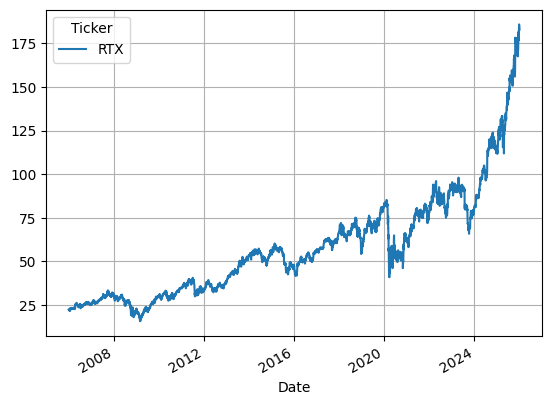

In [ ]:
# Plotting time series of closing daily values of RTX stock 
RTX['Close'].plot(grid = True)
    # We see that the series has an upwards trend, but has really picked up since 2024 

<Axes: xlabel='Date'>

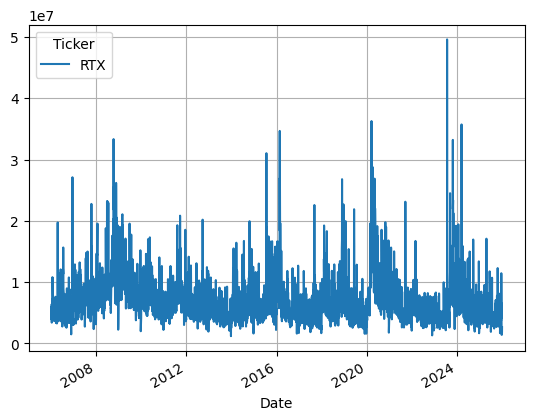

In [18]:
# Plotting time series of volume of RTX stock traded 
RTX['Volume'].plot(grid = True)

Ticker           RTX
Date                
2006-01-03       NaN
2006-01-04 -0.006033
2006-01-05 -0.003744
2006-01-06  0.003210
2006-01-09  0.011331
...              ...
2025-12-24  0.003332
2025-12-26 -0.006513
2025-12-29 -0.004059
2025-12-30 -0.002226
2025-12-31 -0.003320

[5031 rows x 1 columns]


<Axes: xlabel='Date'>

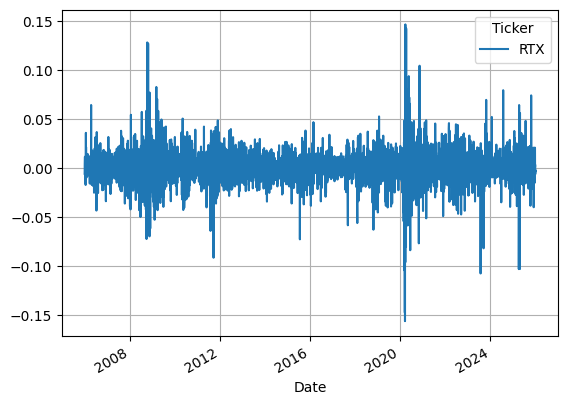

In [20]:
# Calculating and plotting daily log returns

daily_log_returns = np.log(RTX['Close']/RTX['Close'].shift(1))
print(daily_log_returns)
daily_log_returns.plot(grid = True)

<Axes: xlabel='Date'>

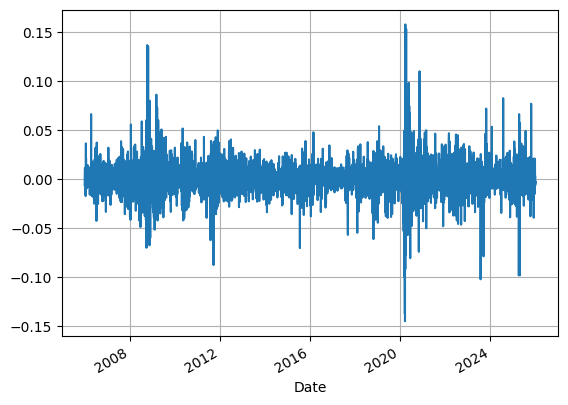

In [22]:
# Calculating actual daily returns 
RTX['Returns'] = RTX['Close'].pct_change()
daily_returns = RTX[['Returns']]
RTX['Returns'].plot(grid = True)

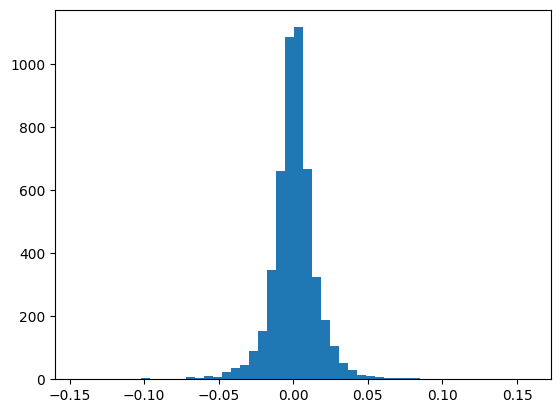

Price       Returns
Ticker             
count   5030.000000
mean       0.000552
std        0.016382
min       -0.144765
25%       -0.006544
50%        0.000529
75%        0.007812
max        0.157572


In [ ]:
# Plotting distribution of returns 
plt.hist(daily_returns, bins = 50)
plt.show()
    # We see that the plot of daily returns follows a normal distribution, aligning with the Central Limit Theorem

# Summary statistics of daily returns 
print(daily_returns.describe())
    # We see that the highest daily return on the RTX stock has been ~ 15% 
    # We see that the greatest daily loss on the RTX stock has been ~14% 

Price        Returns
Ticker              
Date                
2006-01-03       NaN
2006-01-04  0.993986
2006-01-05  0.990271
2006-01-06  0.993455
2006-01-09  1.004776
...              ...
2025-12-24  8.293149
2025-12-26  8.239309
2025-12-29  8.205937
2025-12-30  8.187693
2025-12-31  8.160551

[5031 rows x 1 columns]


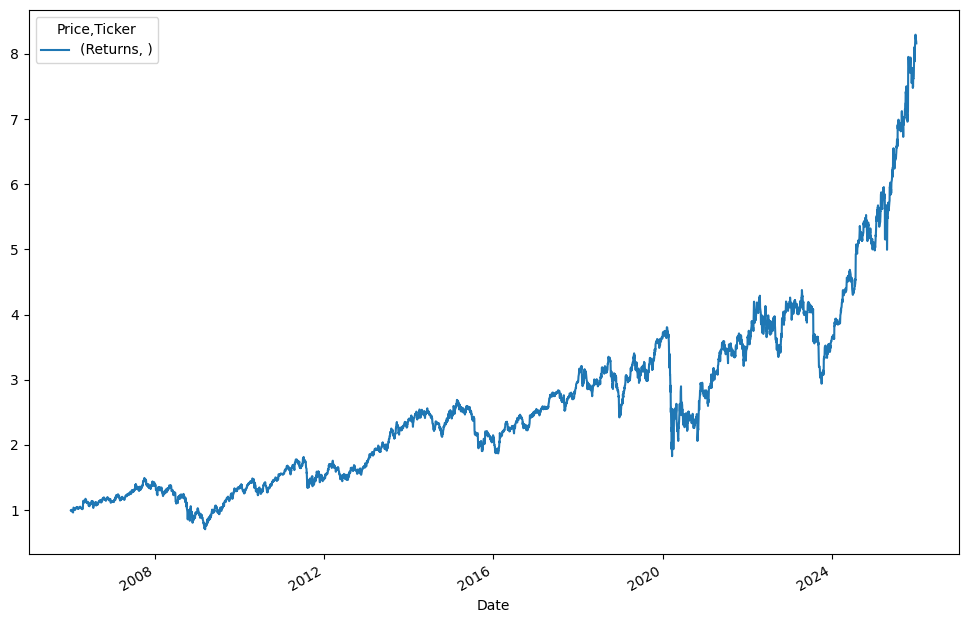

In [24]:
# Calculating cumulative returns 

cum_return = (1 + daily_returns).cumprod()
print(cum_return)

cum_return.plot(figsize = (12,8))
plt.show()

**Multiple stocks:**


In [31]:
all_data = yf.download(['RTX', 'EADSY', 'RYCEY', 'MTUAY', 'SAFRY', 'RNMBY', 'BAESY', 'SAABY', 'THLLY'], start = "2006-01-01", end = "2026-01-01")
print(all_data["Close"])


[*********************100%***********************]  9 of 9 completed

Ticker          BAESY      EADSY       MTUAY       RNMBY         RTX  \
Date                                                                   
2006-01-03  12.612143        NaN         NaN         NaN   22.399574   
2006-01-04  13.154346        NaN         NaN         NaN   22.264853   
2006-01-05  12.965751        NaN         NaN         NaN   22.181652   
2006-01-06  13.555103        NaN         NaN         NaN   22.252979   
2006-01-09  13.507955        NaN         NaN         NaN   22.506561   
...               ...        ...         ...         ...         ...   
2025-12-24  93.370003  57.730000  210.470001  363.929993  185.763000   
2025-12-26  94.250000  58.020000  208.970001  366.630005  184.557007   
2025-12-29  93.089996  57.560001  208.080002  357.899994  183.809494   
2025-12-30  93.559998  58.310001  208.970001  366.880005  183.400833   
2025-12-31  92.879997  57.919998  208.429993  365.500000  182.792862   

Ticker          RYCEY      SAABY      SAFRY      THLLY  
Date  

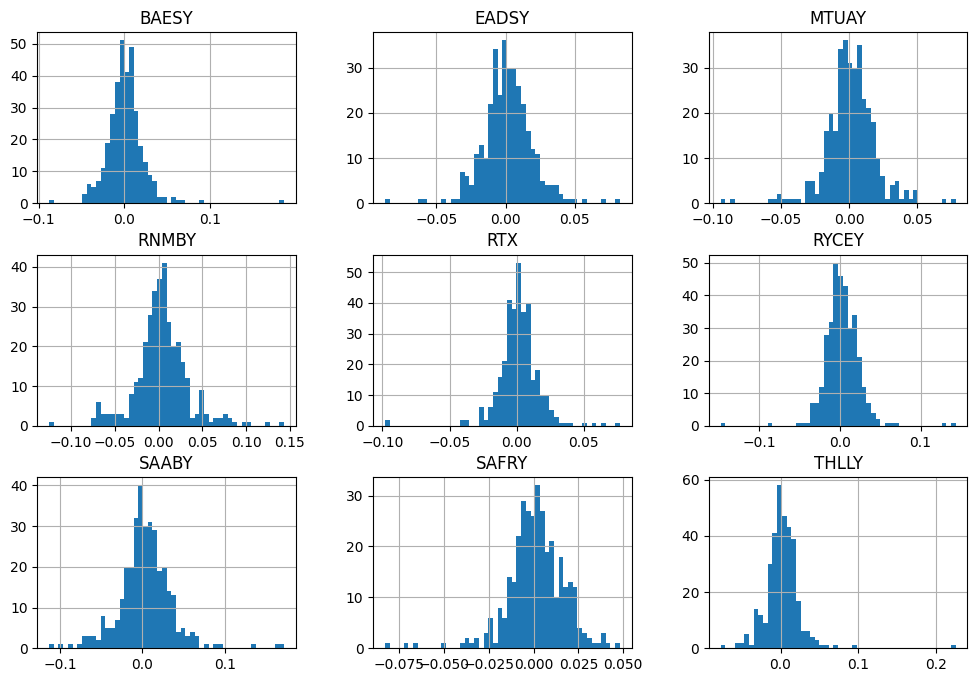

In [35]:
daily_close_px = all_data['Close']

daily_pct_change = daily_close_px.pct_change()

daily_pct_change.dropna().hist(bins=50, figsize=(12,8))

plt.show()

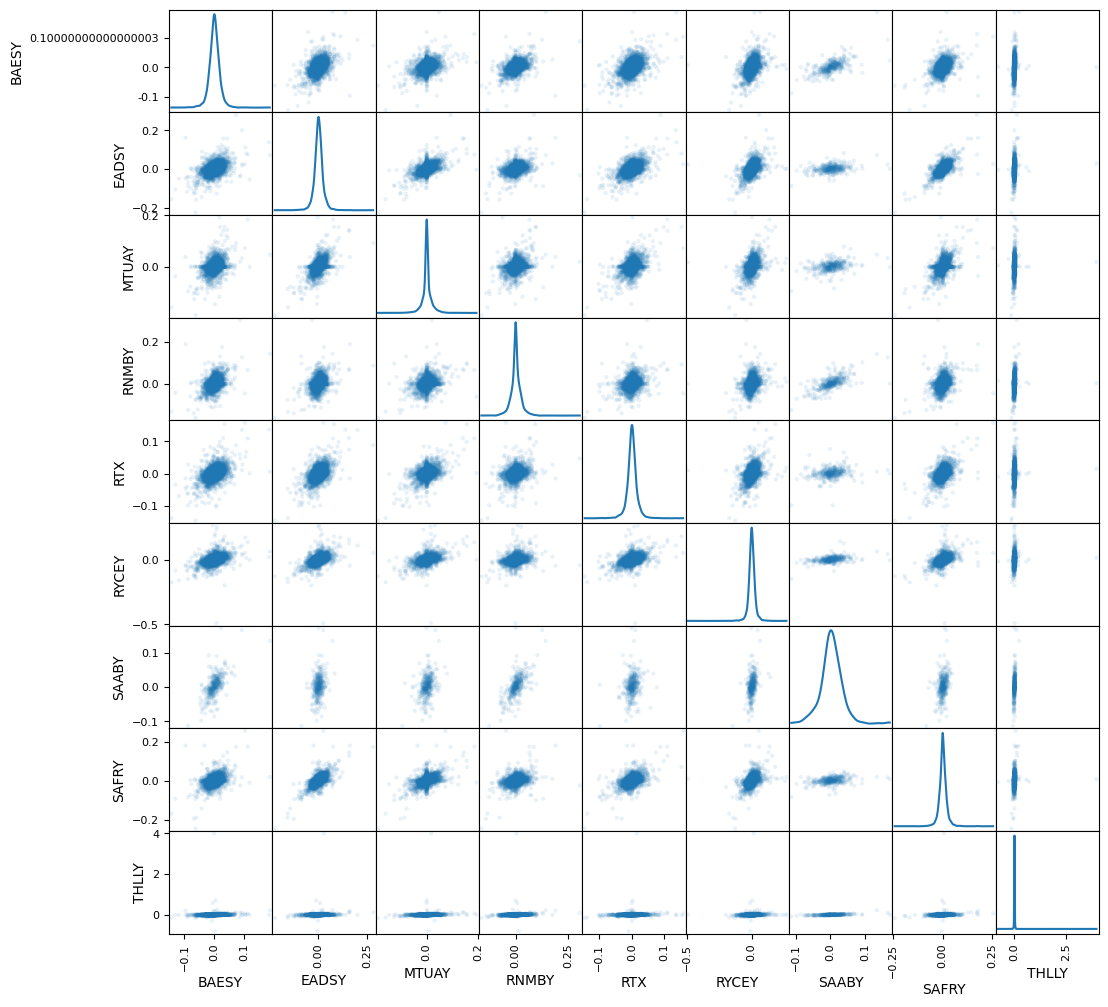

In [36]:
# Plotting a scatter matrix with the daily_pct_change data: 
pd.plotting.scatter_matrix(daily_pct_change, diagonal='kde', alpha=0.1,figsize=(12,12))
plt.show()


**Moving windows:**

C:\Users\abhik\AppData\Local\Temp\ipykernel_229788\1018212564.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  close_px.fillna(0, inplace = True)


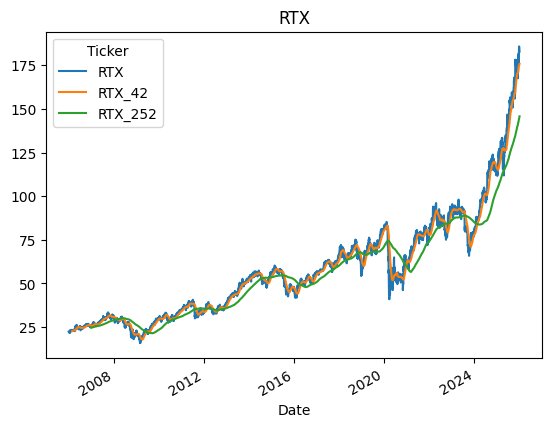

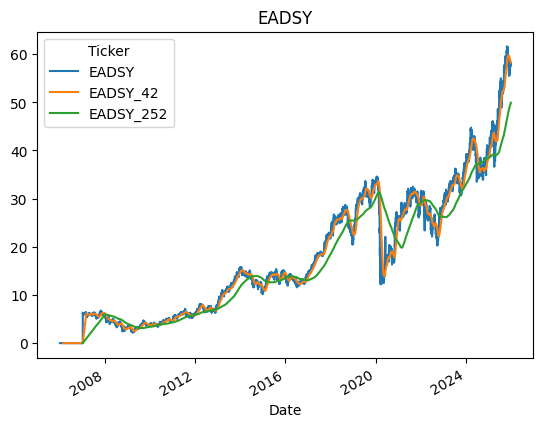

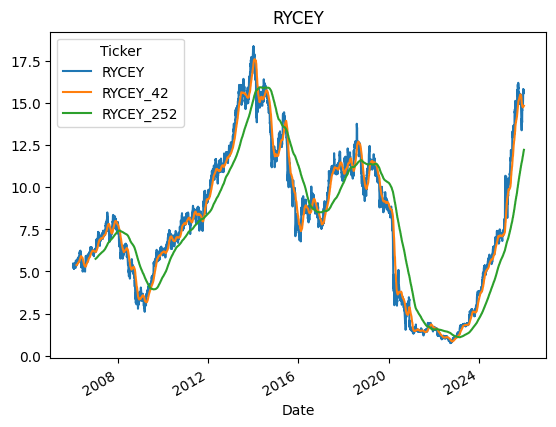

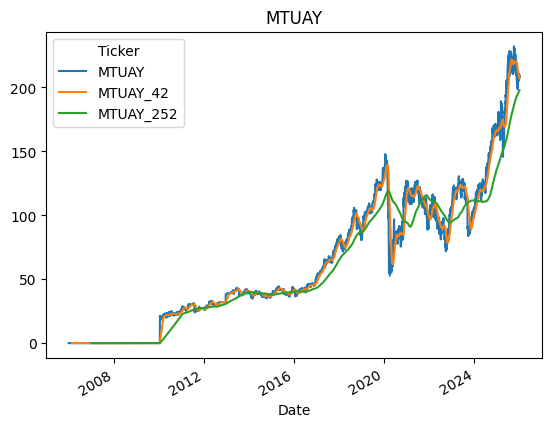

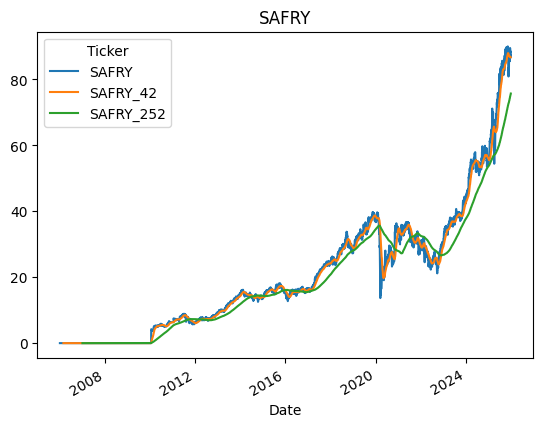

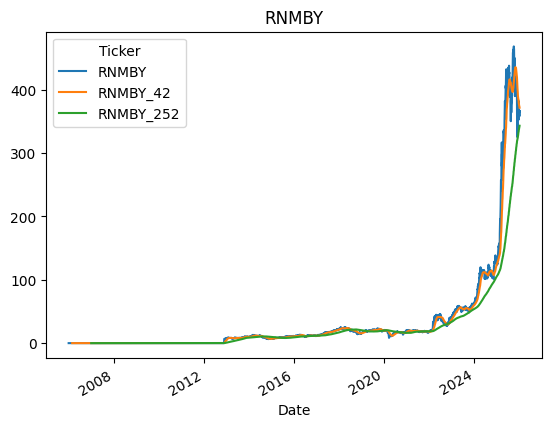

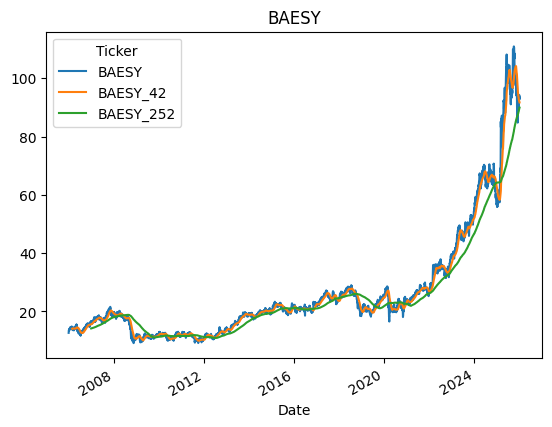

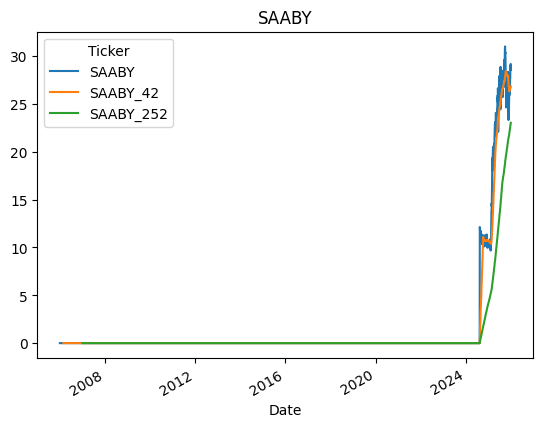

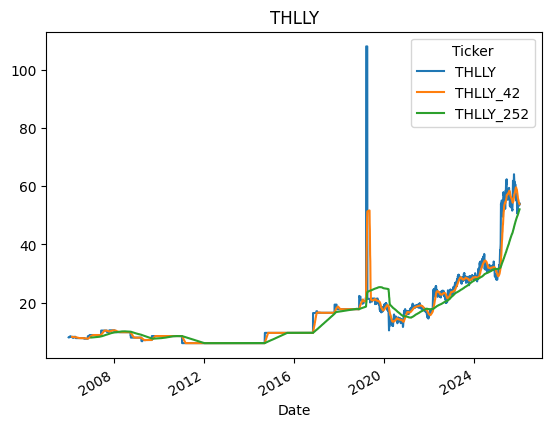

In [45]:
close_px = all_data['Close']
close_px.fillna(0, inplace = True)

for i in tickers:
    ma_42 = close_px[i].rolling(window=40).mean()
    ma_252 = close_px[i].rolling(window=252).mean()

    df = close_px[[i]].copy()
    df[f"{i}_42"] = ma_42
    df[f"{i}_252"] = ma_252

    df.plot(title=i)

plt.show()

**Volatility:**

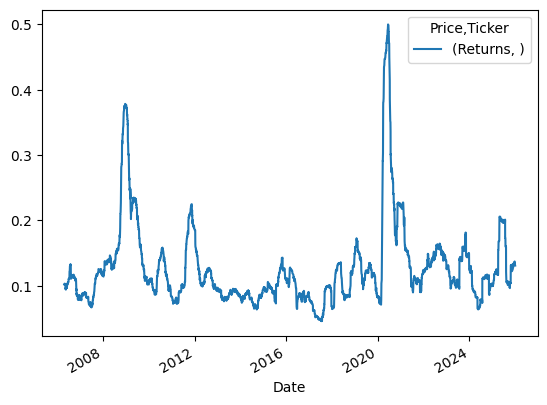

In [ ]:
# Calculating volatility: 
min_periods = 75
vol = daily_returns.rolling(min_periods).std() * np.sqrt(min_periods)

# Plotting volatility: 
vol.plot()
plt.show()

**Building a Simple Trading Strategy - Single Stock (RTX):** 

In [48]:
RTX.head()

Price,Close,High,Low,Open,Volume,Returns
Ticker,RTX,RTX,RTX,RTX,RTX,
Date,,,,,,
2006-01-03,22.399574,22.451087,21.975596,22.367877,5905519,NaN
2006-01-04,22.264853,22.506560,22.126168,22.506560,4948941,-0.006014
2006-01-05,22.181652,22.383734,22.042967,22.308448,4955932,-0.003737
2006-01-06,22.252979,22.455063,22.229203,22.367891,4567263,0.003216
2006-01-09,22.506561,22.546187,22.252967,22.336179,3920381,0.011395


In [50]:
short_window = 40
long_window = 252

# Creating a DF called "signals" which includes a column called "signal"
signals = pd.DataFrame(index = RTX.index)
signals['signal'] = 0.0

# Creating a short simple moving average over the short window: 
signals['short_MA'] = RTX['Close'].rolling(window = short_window, min_periods = 1, center = False).mean()

# Creating a long simple moving average over the short window: 
signals['long_MA'] = RTX['Close'].rolling(window = long_window, min_periods = 1, center = False).mean()

# Creating signals: 
signals['signal'][short_window:] = np.where(signals['short_MA'][short_window:] > signals['long_MA'][short_window:], 1.0, 0.0)

# Trading orders: 
signals['positions'] = signals['signal'].diff()

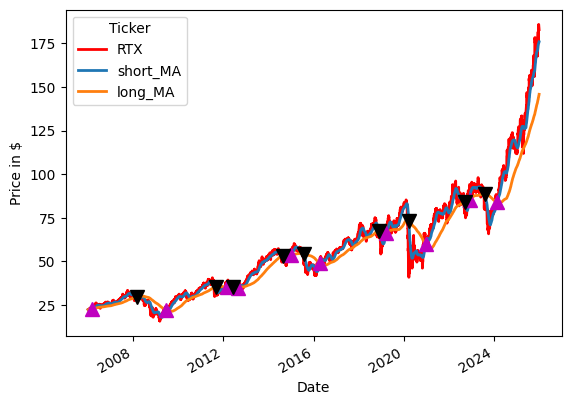

In [52]:
# Plotting the short and long moving averages, as well as the buying and selling signals: 

fig = plt.figure()

ax1 = fig.add_subplot(111, ylabel = 'Price in $')

RTX['Close'].plot(ax = ax1, color = 'red', lw = 2.)

signals[['short_MA', 'long_MA']].plot(ax = ax1, lw = 2.)

# Plotting buy signals: 
ax1.plot(signals.loc[signals.positions == 1.0].index, signals.short_MA[signals.positions == 1.0], '^', markersize = 10, color = 'm')

# Plotting sell signals: 
ax1.plot(signals.loc[signals.positions == -1.0].index, signals.short_MA[signals.positions == -1.0], 'v', markersize = 10, color = 'k')

plt.show()

*Backtesting the strategy:*

In [54]:
# Setting initial capital: 
initial_capital = float(100000.0)

# Creating a DataFrame: 
positions = pd.DataFrame(index = signals.index).fillna(0.0)

# Starting off with buying 100 Apple shares: 
positions['RTX'] = 100*signals['signal']   
  
# Initialize the portfolio with value owned   
portfolio = positions.multiply(RTX['Close'], axis=0)

# Store the difference in shares owned 
pos_diff = positions.diff()

# Add `holdings` to portfolio
portfolio['holdings'] = (positions.multiply(RTX['Close'], axis=0)).sum(axis=1)

# Add `cash` to portfolio
portfolio['cash'] = initial_capital - (pos_diff.multiply(RTX['Close'], axis=0)).sum(axis=1).cumsum()   

# Add `total` to portfolio
portfolio['total'] = portfolio['cash'] + portfolio['holdings']

# Add `returns` to portfolio
portfolio['returns'] = portfolio['total'].pct_change()

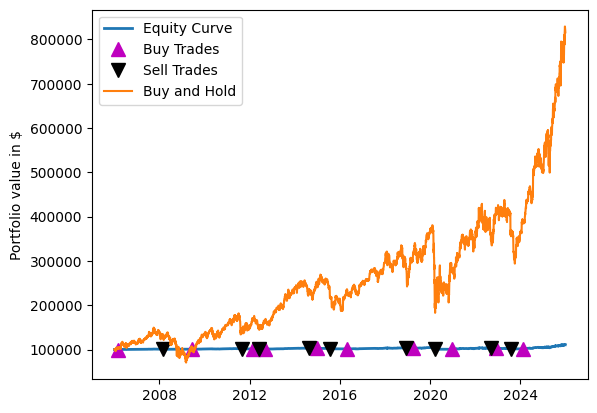

In [59]:
fig = plt.figure()

ax1 = fig.add_subplot(111, ylabel='Portfolio value in $')

# Plot the equity curve in dollars
ax1.plot(portfolio['total'], lw=2., label='Equity Curve')

# Plot the "buy" trades against the equity curve
ax1.plot(portfolio.loc[signals.positions == 1.0].index, 
         portfolio.total[signals.positions == 1.0],
         '^', markersize=10, color='m', label='Buy Trades')

# Plot the "sell" trades against the equity curve
ax1.plot(portfolio.loc[signals.positions == -1.0].index, 
         portfolio.total[signals.positions == -1.0],
         'v', markersize=10, color='k', label='Sell Trades')

# Plot the Buy and Hold strategy
buy_and_hold = initial_capital * (RTX['Close'] / RTX['Close'].iloc[0])
ax1.plot(buy_and_hold, label='Buy and Hold')

# Add legend
ax1.legend()

# Show the plot
plt.show()

It looks like our strategy has performed poorly! We see that our portfolio not only fell in value, but failed to beat the basic strategy of buying the stock and holding it. 

*Evaluating the Moving Average Crossover Strategy:*

Sharpe Ratio: 

In [ ]:
returns = portfolio['returns']

# Annualised Sharpe Ratio: 
sharpe_ratio = np.sqrt(252) * (returns.mean()/ returns.std())
print(sharpe_ratio)

0.39805635563606484


Maximum Drawdown: 

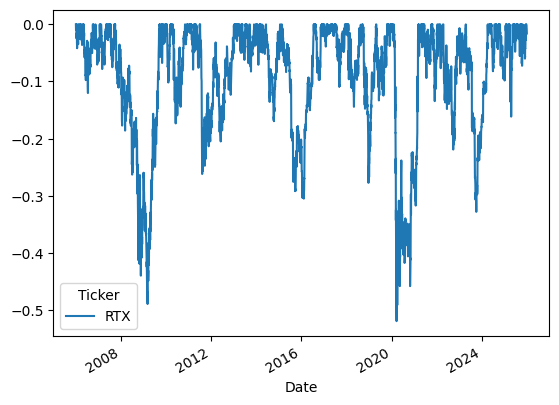

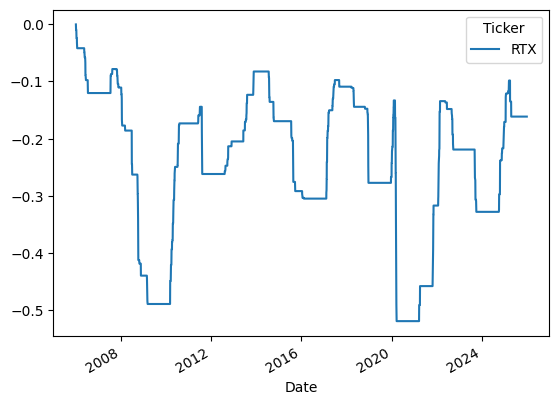

In [63]:
window = 252 

rolling_max = RTX['Close'].rolling(window, min_periods = 1).max()
daily_drawdown = RTX['Close']/rolling_max - 1.0

max_daily_drawdown = daily_drawdown.rolling(window, min_periods = 1).min()

daily_drawdown.plot()
max_daily_drawdown.plot()

plt.show()

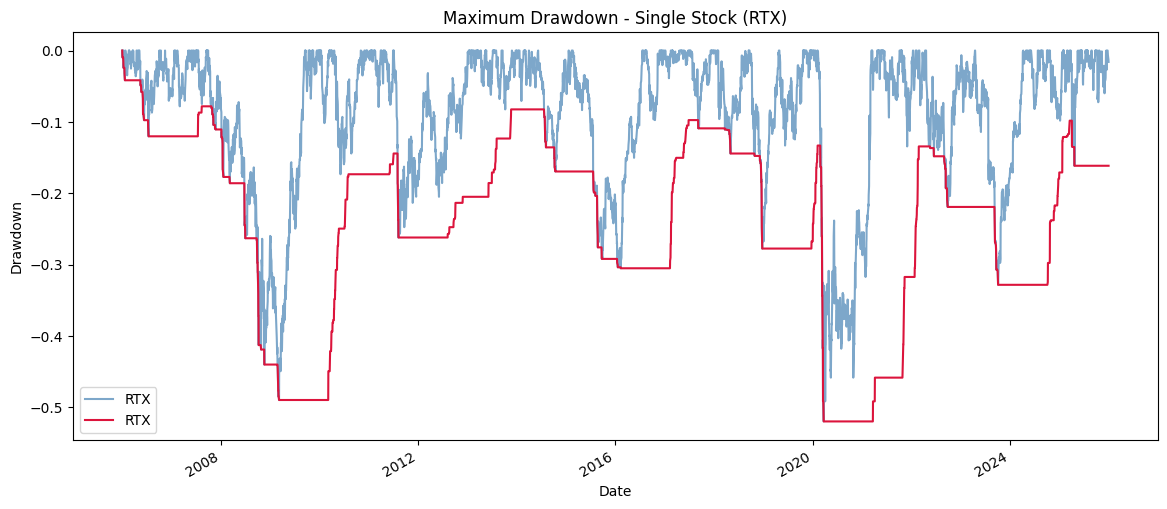

In [107]:
window = 252
rolling_max = RTX['Close'].rolling(window, min_periods=1).max()
daily_drawdown = RTX['Close'] / rolling_max - 1.0
max_daily_drawdown = daily_drawdown.rolling(window, min_periods=1).min()

# Create a figure and axis object
fig, ax = plt.subplots(figsize = (14,6))

# Plot both series on the same axis
daily_drawdown.plot(ax=ax, label="Daily Drawdown", color = "steelblue", alpha = 0.7)
max_daily_drawdown.plot(ax=ax, label="Max Daily Drawdown", color = "crimson", linewidth = 1.5 )

# Adding labels and legend
ax.set_title("Maximum Drawdown - Single Stock (RTX)")
ax.set_xlabel('Date')
ax.set_ylabel('Drawdown')
ax.legend()

# Show the plot
plt.show()

*Compound Annual Growth Rate (CAGR):*

In [70]:
# Number of days in series: 
days = len(RTX)
print(days)
    # There are 5031 rows in the scraped dataset, with one observation per day, indicating that we have 5031 days 

# Calculate the CAGR 
cagr = ((((RTX['Close'].iloc[-1]) / RTX['Close'].iloc[1])) ** (365.0/days)) - 1
print(cagr)

5031
Ticker
RTX    0.165026
dtype: float64


**Building a Simple Trading Strategy - Multiple Stocks:**

In [95]:
daily_close_px_clean = daily_close_px.dropna(axis = 1, thresh = 500)
    # Removing NA values just in case there are any remaining 
portfolio_price = daily_close_px_clean.mean(axis = 1)
    # Here, I build a portfolio with equal weighting across the different stocks 

In [96]:
# Calculating moving averages: 

AS_short_MA = portfolio_price.rolling(40, min_periods = 20).mean()
AS_long_MA = portfolio_price.rolling(252, min_periods = 126).mean()

# NOTE: I have used the abbrieviation "AS" as a label for "All stocks" to avoid overwriting previous variables


In [97]:
# Computing returns: 

returns = daily_close_px_clean.pct_change()

In [98]:
# Generating signals: 

AS_signals = pd.DataFrame(index=portfolio_price.index)
AS_signals['signal'] = 0.0

AS_signals['short_MA'] = AS_short_MA
AS_signals['long_MA'] = AS_long_MA

AS_signals['signal'][40:] = np.where(
    AS_signals['short_MA'][40:] > AS_signals['long_MA'][40:], 1.0, 0.0
)

AS_signals['positions'] = AS_signals['signal'].diff()

In [99]:
weights = AS_signals.div(AS_signals.sum(axis=1), axis=0)
weights = weights.fillna(0)

In [100]:
# Applying to all stocks:

n_stocks = returns.shape[1]
signal_aligned = AS_signals['signal'].reindex(returns.index).fillna(0)

# Equal-weighting returns across all stocks:
equal_weight_returns = returns.mean(axis=1)   
    # equal-weight portfolio return each day
strategy_returns = equal_weight_returns * signal_aligned 
    # 0 return when signal is out

benchmark_returns = returns.mean(axis=1)  # buy-and-hold equal weight benchmark


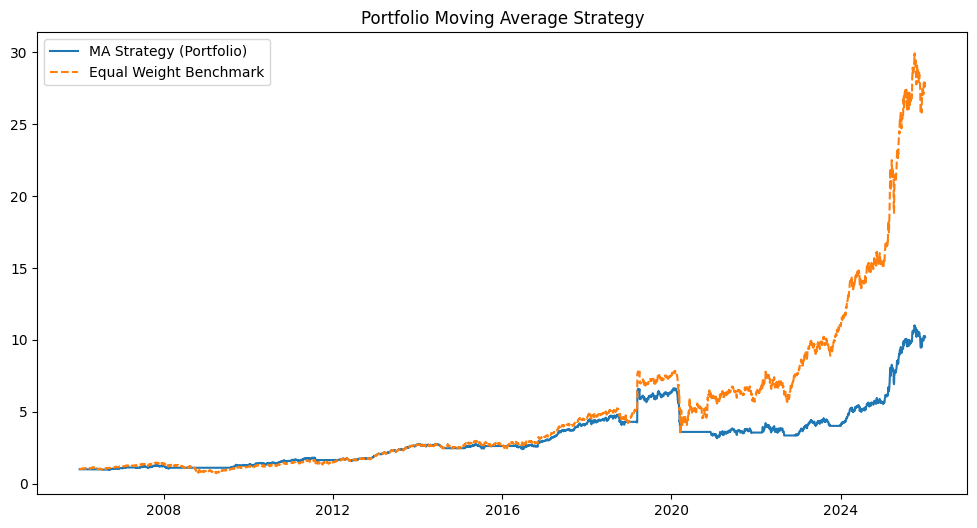

In [101]:
# Performance: 

strategy_cum = (1 + strategy_returns).cumprod()
benchmark_cum = (1 + benchmark_returns).cumprod()

plt.figure(figsize=(12,6))
plt.plot(strategy_cum, label='MA Strategy (Portfolio)')
plt.plot(benchmark_cum, label='Equal Weight Benchmark', linestyle='--')
plt.legend()
plt.title("Portfolio Moving Average Strategy")
plt.show()

Whilst this strategy performed better than the first one relative to its benchmark, it still failed to beat it, indicating the weaknesses of this type of strategy as they have led to late entries/exits.

Sharpe Ratio: 

In [ ]:
allstocks_sharpe = np.sqrt(252) * strategy_returns.mean() / strategy_returns.std()
print("Sharpe Ratio:", allstocks_sharpe)
    # This Sharpe ratio is almost double the ratio in our first MA strategy with only the RTX stock
    # However, this ratio is still considered to be sub-optimal by standard investment benchmarks 
    # This is because the ratio indicates that we are receiving around 0.68 units of excess return for every 1 unit of risk taken

Sharpe Ratio: 0.6773425816684568


Maximum Drawdown: 

In [103]:
# Maximum drawdown: 

cum_max = strategy_cum.cummax()
allstocks_drawdown = (strategy_cum - cum_max) / cum_max
print("Max Drawdown:", allstocks_drawdown.min())

Max Drawdown: -0.5226491459802497


In [108]:
allstocks_maxdrawdown = allstocks_drawdown.rolling(window, min_periods = 1).min()

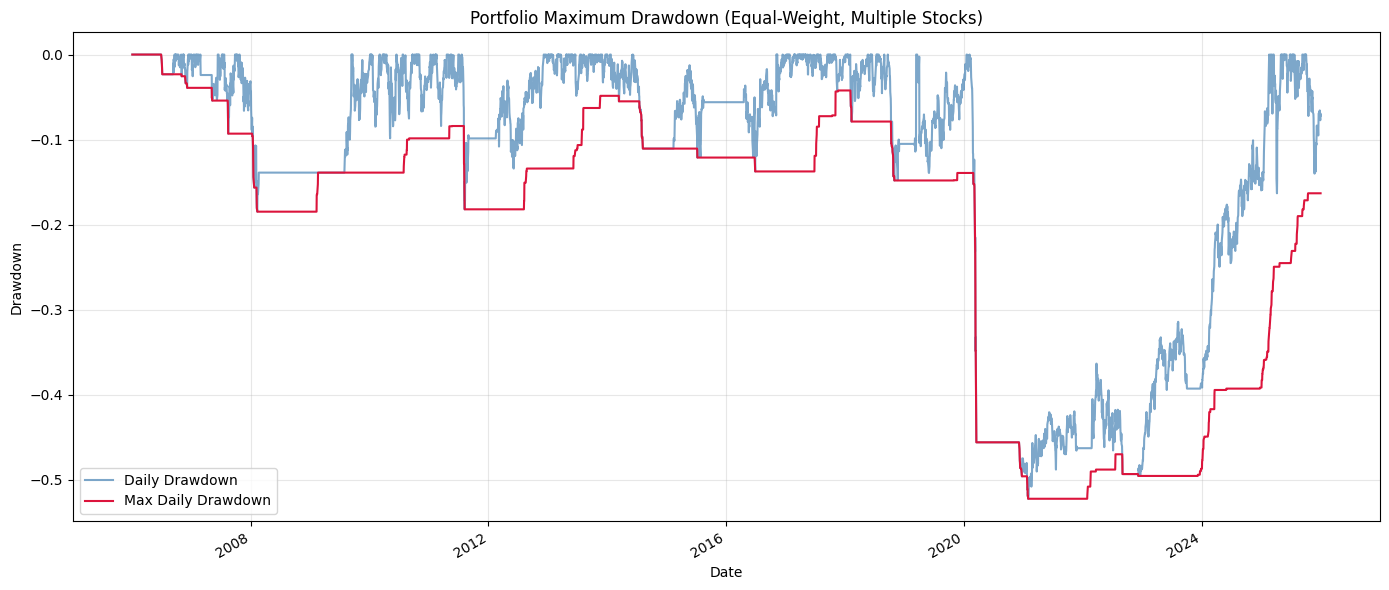

In [109]:
fig, ax = plt.subplots(figsize=(14, 6))
 
allstocks_drawdown.plot(ax=ax, label="Daily Drawdown", color="steelblue", alpha=0.7)
allstocks_maxdrawdown.plot(ax=ax, label="Max Daily Drawdown", color="crimson", linewidth=1.5)
 
ax.set_xlabel("Date")
ax.set_ylabel("Drawdown")
ax.set_title("Portfolio Maximum Drawdown (Equal-Weight, Multiple Stocks)")
ax.legend()
ax.grid(True, alpha=0.3)
 
plt.tight_layout()
plt.savefig("portfolio_drawdown.png", dpi=150)
plt.show()